# Homework 2: AGN Variabilty in DP2

In [2]:
%pip list | grep -E 'lsdb|nested|hats'
!echo
!which python

hats                              0.8.2
hats-import                       0.8.2
lsdb                              0.8.3.dev6+g98e7fc092         /home/o/olynn/CODE/lsdb
nested-pandas                     0.6.8
Note: you may need to restart the kernel to use updated packages.

/usr/local/share/jupyterlab/venv/bin/python


In [3]:
import lsdb

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: proxy/8787/status,
Dashboard: proxy/8787/status,Workers: 4
Total threads: 4,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42201,Workers: 0
Dashboard: proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41531,Total threads: 1
Dashboard: proxy/43141/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:42905,


In [5]:
import os

# Get the base URL from the environment
base_url = os.environ.get('JUPYTERHUB_SERVICE_PREFIX', '')
dashboard_url = f"https://usdf-rsp.slac.stanford.edu{base_url}proxy/8787/status"
print(f"Dask Dashboard: {dashboard_url}")

Dask Dashboard: https://usdf-rsp.slac.stanford.edu/nb/user/olynn/proxy/8787/status


## Get catalog: GAIA AGN Remote

The following are the default available columns in the GAIA AGN catalog:

| Column | Description |
|--------|-------------|
| _RAJ2000 | Right Ascension (J2000), added by CDS for cone search |
| _DEJ2000 | Declination (J2000), added by CDS for cone search |
| Source | Gaia source ID |
| SolID | Gaia processing solution ID |
| fvarG | Fractional variability in the G band |
| SFIndex | Structure Function index (characterizes variability slope/shape) |
| s_SFIndex | Uncertainty on SFIndex |
| QSOVar | Variability score favouring QSO-like variability |
| NonQSOVar | Variability score favouring non-QSO (e.g. stellar) variability |
| RA_ICRS | Right Ascension in the ICRS frame (from Gaia) |
| DE_ICRS | Declination in the ICRS frame (from Gaia) |

We will select only a subset of them, to save on storage space.

In [ ]:
gaia_agn_remote_path = "https://vizcat.cds.unistra.fr/hats/I/358/vagn/"

gaia_agn_remote = lsdb.open_catalog(gaia_agn_remote_path, columns=["_RAJ2000", "_DEJ2000", "RA_ICRS", "DE_ICRS"])

In [ ]:
gaia_agn_remote.per_pixel_statistics()

In [ ]:
# Above error: ArrowInvalid: Parquet magic bytes not found in footer. Either the file is corrupted or this is not a parquet file.

# Not ideal. Just checking if this is even a valid HATS catalog...

from hats.io.validation import is_valid_catalog
import hats
from upath import UPath

is_valid_catalog(gaia_agn_remote_path)

In [ ]:
# Well. Sean does say there's some weirdness with HATS on the fly stuff. That makes some sense here.

# I could track this down, or just save the catalog and move on.

## Save catalog: GAIA AGN Remote

In [ ]:
#gaia_agn.write_catalog("catalogs/", catalog_name="gaia_agn")

## Get catalog: GAIA AGN Local

In [6]:
gaia_agn_local_path = "./catalogs/gaia_agn"
gaia_agn_local = lsdb.open_catalog(gaia_agn_local_path, columns=["_RAJ2000", "_DEJ2000", "RA_ICRS", "DE_ICRS"])

### Inspect GAIA AGN as HATS

In [21]:
# Check if valid HATS catalog

from hats.io.validation import is_valid_catalog


print("Valid HATS?", is_valid_catalog(gaia_agn_local_path))

Valid HATS? True


In [22]:
# Get quick column statistics

gaia_agn_local_hats = hats.read_hats(gaia_agn_local_path)
gaia_agn_local_hats.aggregate_column_statistics()

,min_value,max_value,null_count,row_count
column_names,,,,
_RAJ2000,0.000207,359.999800,0,872228
_DEJ2000,-89.870936,89.835569,0,872228
RA_ICRS,0.000207,359.999800,0,872228
DE_ICRS,-89.870936,89.835569,0,872228


In [23]:
# Look at per-pixel information

from hats.pixel_math import HealpixPixel

info_frame = gaia_agn_local_hats.partition_info.as_dataframe()

for index, partition in info_frame.iterrows():
    file_name = result = hats.io.paths.pixel_catalog_file(
        gaia_agn_local_path, HealpixPixel(partition["Norder"], partition["Npix"])
    )
    info_frame.loc[index, "size_on_disk"] = os.path.getsize(file_name)

info_frame = info_frame.astype(int)
info_frame["gbs"] = info_frame["size_on_disk"] / (1024 * 1024 * 1024)

info_frame

,Norder,Npix,size_on_disk,gbs
0,0,0,1486205,0.001384
1,0,1,4067950,0.003789
2,0,2,4696589,0.004374
3,0,3,1644567,0.001532
4,0,4,3349988,0.003120
5,0,5,2033320,0.001894
6,0,6,3529096,0.003287
7,0,7,1115208,0.001039
8,0,8,4514197,0.004204
9,0,9,1857837,0.001730


In [24]:
# Summarize above per-pixel information

print(f'healpix orders: {info_frame["Norder"].unique()}')
print(f'num partitions: {len(info_frame["Npix"])}')
print("------")
print(f'min size_on_disk: {info_frame["gbs"].min():.2f}')
print(f'max size_on_disk: {info_frame["gbs"].max():.2f}')
print(f'size_on_disk ratio: {info_frame["gbs"].max()/info_frame["gbs"].min():.2f}')
print(f'total size_on_disk: {info_frame["gbs"].sum():.2f}')

healpix orders: [0]
num partitions: 12
------
min size_on_disk: 0.00
max size_on_disk: 0.00
size_on_disk ratio: 4.89
total size_on_disk: 0.03


small-ish 	: 12 	(100.0 %)
sweet-spot 	: 0 	(0.0 %)
big-ish 	: 0 	(0.0 %)
too-big 	: 0 	(0.0 %)


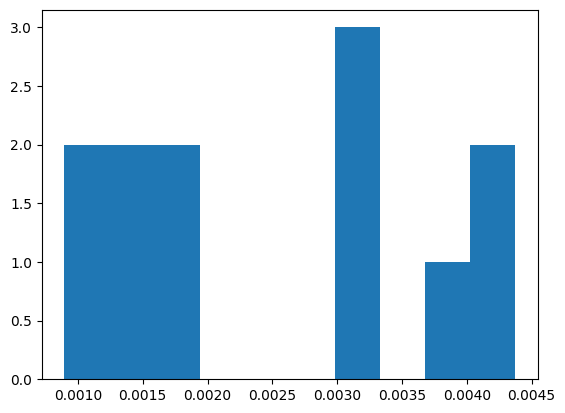

In [25]:
# Check out partitioning, just to see

import matplotlib.pyplot as plt
import numpy as np

plt.hist(info_frame["gbs"])

bins = [0, 0.5, 1, 2, 100]
labels = ["small-ish", "sweet-spot", "big-ish", "too-big"]
hist = np.histogram(info_frame["gbs"], bins=bins)[0]
pcts = hist / len(info_frame)
for i in range(0, len(labels)):
    print(f"{labels[i]} \t: {hist[i]} \t({pcts[i]*100:.1f} %)")

### Inspect GAIA AGN as LSDB Catalog

In [12]:
# View per-pixel statistics--this was the method that was failing for us for the remote catalog

gaia_agn_local.per_pixel_statistics()

,_RAJ2000: min_value,_RAJ2000: max_value,_RAJ2000: null_count,_RAJ2000: row_count,_RAJ2000: disk_bytes,_RAJ2000: memory_bytes,_DEJ2000: min_value,_DEJ2000: max_value,_DEJ2000: null_count,_DEJ2000: row_count,...,RA_ICRS: null_count,RA_ICRS: row_count,RA_ICRS: disk_bytes,RA_ICRS: memory_bytes,DE_ICRS: min_value,DE_ICRS: max_value,DE_ICRS: null_count,DE_ICRS: row_count,DE_ICRS: disk_bytes,DE_ICRS: memory_bytes
"Order: 0, Pixel: 0",0.002779,89.999121,0,39222,372403.0,392400.0,0.237432,89.778717,0,39222,...,0,39222,372344.0,392400.0,0.237432,89.778717,0,39222,370221.0,392400.0
"Order: 0, Pixel: 1",90.001759,179.999665,0,108714,1014897.0,1101056.0,0.012617,89.718933,0,108714,...,0,108714,1013598.0,1101056.0,0.012617,89.718933,0,108714,1018867.0,1101056.0
"Order: 0, Pixel: 2",114.527322,269.998960,0,124501,1168872.0,1260925.0,0.148996,89.835569,0,124501,...,0,124501,1168866.0,1260925.0,0.148996,89.835569,0,124501,1178922.0,1260925.0
"Order: 0, Pixel: 3",205.451431,359.999800,0,43947,407659.0,439666.0,0.060415,89.831474,0,43947,...,0,43947,406344.0,439666.0,0.060415,89.831474,0,43947,414763.0,439666.0
"Order: 0, Pixel: 4",0.000207,359.999756,0,88437,831319.0,895705.0,-41.575599,89.553675,0,88437,...,0,88437,831323.0,895705.0,-41.575599,89.553675,0,88437,843168.0,895705.0
"Order: 0, Pixel: 5",45.124213,134.867794,0,53406,502179.0,534268.0,-41.792165,41.137640,0,53406,...,0,53406,502201.0,534268.0,-41.792165,41.137640,0,53406,513982.0,534268.0
"Order: 0, Pixel: 6",90.227502,224.725235,0,93810,868613.0,950124.0,-41.646155,41.692191,0,93810,...,0,93810,870256.0,950124.0,-41.646155,41.692191,0,93810,894572.0,950124.0
"Order: 0, Pixel: 7",179.986009,314.751423,0,31002,267166.0,306316.0,-39.668863,41.772355,0,31002,...,0,31002,267160.0,306316.0,-39.668863,41.772355,0,31002,289882.0,306316.0
"Order: 0, Pixel: 8",0.000262,269.941704,0,119795,1131221.0,1213271.0,-89.771636,41.577242,0,119795,...,0,119795,1131255.0,1213271.0,-89.771636,41.577242,0,119795,1125429.0,1213271.0
"Order: 0, Pixel: 9",44.954769,179.999492,0,49270,461612.0,492900.0,-89.745651,-0.140343,0,49270,...,0,49270,461654.0,492900.0,-89.745651,-0.140343,0,49270,467062.0,492900.0


## Get catalog: DP2

The default columns in the LSST DP2 catalog:

| Column | Description |
|--------|-------------|
| diaObjectId | Unique identifier for the DIА object |
| ra | Right Ascension (degrees) |
| dec | Declination (degrees) |
| tract | Sky map tract number |
| nDiaSources | Number of difference image detections (epochs) |
| diaObjectForcedSource | Nested: forced photometry at this position across visits (light curve) |
| diaSource | Nested: difference image detections across visits (transient/variability detections) |

Again, we'll select only a subset.

In [33]:
dp2_path = '/sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_0_rc2/dia_object_collection'
dp2 = lsdb.open_catalog(dp2_path, columns=["diaObjectId", "ra", "dec", "diaObjectForcedSource"])
dp2

,diaObjectId,ra,dec,diaObjectForcedSource
npartitions=7725,,,,
"Order: 7, Pixel: 68159",int64[pyarrow],double[pyarrow],double[pyarrow],"nested<parentObjectId: [int64], coord_ra: [dou..."
"Order: 4, Pixel: 1065",...,...,...,...
...,...,...,...,...
"Order: 5, Pixel: 12240",...,...,...,...
"Order: 5, Pixel: 12256",...,...,...,...


## Get catalog: GAIA Full

In [7]:
gaia_full = lsdb.open_catalog('https://data.lsdb.io/hats/gaia_dr3')

## Examine catalogs

(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of gaia_agn'}>)

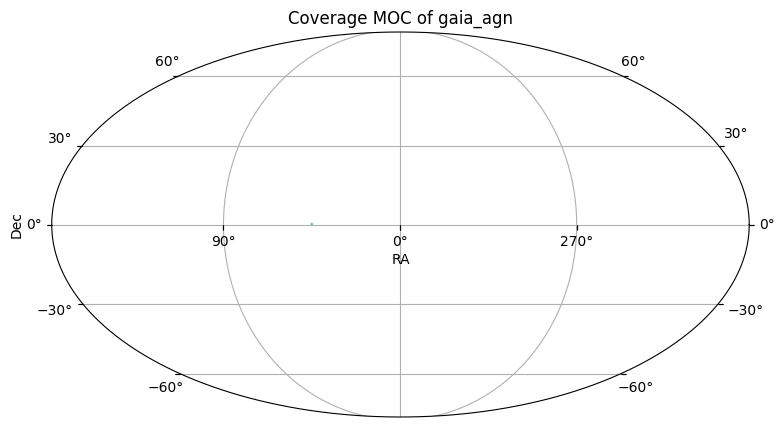

In [26]:
gaia_agn_local.plot_coverage()

(<Figure size 1000x500 with 2 Axes>,
 <WCSAxes: title={'center': 'Catalog pixel map - gaia_agn'}>)

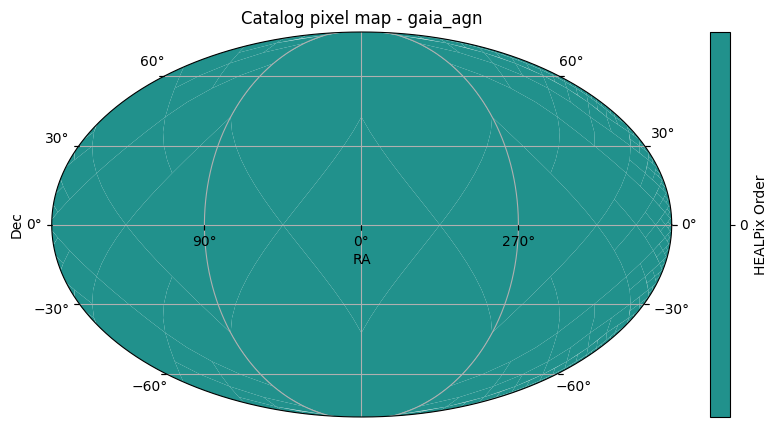

In [15]:
gaia_agn_local.plot_pixels()
#gaia_agn_local.plot_points()

(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of dia_object_lc'}>)

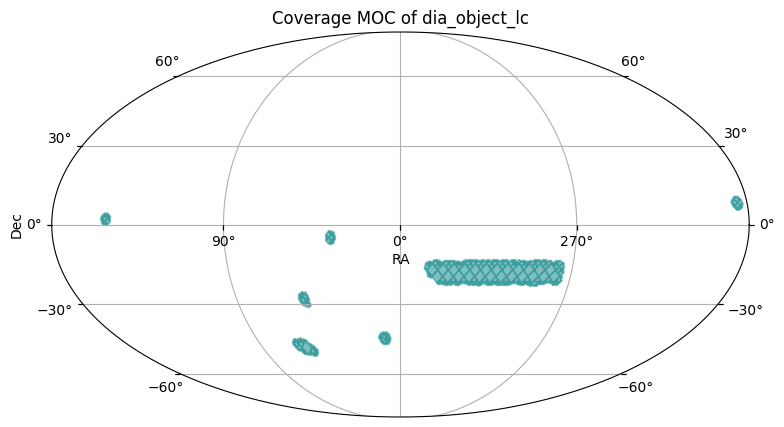

In [34]:
dp2.plot_coverage()

(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of gaia'}>)

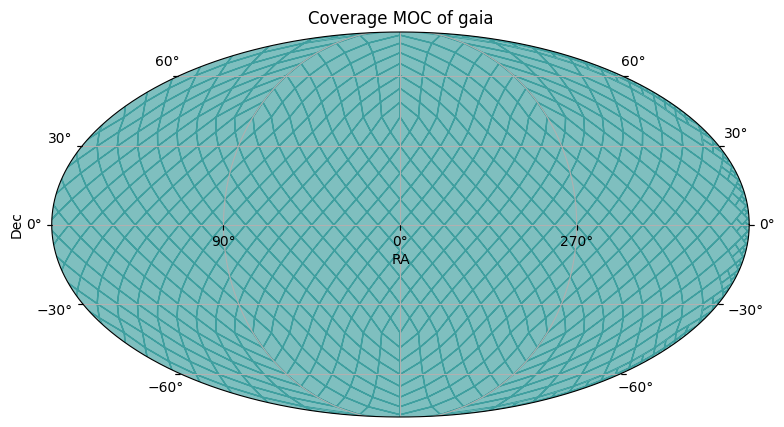

In [11]:
gaia_full.plot_coverage()

## Run crossmatch: GAIA AGN x DP2

In [ ]:
gaia_agn_x_dp2 = gaia_agn.crossmatch(dp2, radius_arcsec=5, output_catalog_name="gaia_agn_x_dp2", suffix_method="overlapping_columns")
gaia_agn_x_dp2

In [ ]:
gaia_agn_x_dp2.plot_coverage()

In [ ]:
gaia_agn_x_dp2.plot_pixels()

In [ ]:
#gaia_agn_x_dp2.plot_points()

In [ ]:
#df = gaia_agn_x_dp2.head(5)
#df

# generates a small task graph, but gets stuck trying the first 3 tasks, then restarting - maybe it takes a while to find objects that can actually be crossmatched?

In [ ]:
# gaia_agn_x_dp2.write_catalog("xmatched_catalogs/", catalog_name="gaia_agn_x_dp2")

# keeps getting the concat empty issue. maybe there's juuuust too much data for the last step? gonna try a cone search...

## Run crossmatch (GAIA AGN x DP2) with cone search

In [ ]:
gaia_agn_x_dp2_cone = gaia_agn_x_dp2.cone_search(ra=-30, dec=-18, radius_arcsec=5 * 3600)
gaia_agn_x_dp2_cone

In [ ]:
gaia_agn_x_dp2_cone.plot_pixels()

In [ ]:
#gaia_agn_x_dp2_cone.plot_points()

In [8]:
## Run crossmatch: (GAIA AGN x GAIA Full) with cone search

In [1]:
gaia_agn_x_gaia_full = gaia_agn.crossmatch(gaia_full, radius_arcsec=5, output_catalog_name="gaia_agn_x_gaia_full", suffix_method="overlapping_columns")

NameError: name 'gaia_agn' is not defined

## Read in crossmatched catalog

In [ ]:
#gxd_cat = lsdb.open_catalog("./gaia_agn_x_dp2")

## Investigate what went wrong

### Tuesday

In [ ]:
# if we're getting an error about empty concat in concat_partition_and_margin, do we have an issue with the margin catalog? though, would that be enough to end up with an empty xmatch cat?

dp2.margin

# well...

In [ ]:
dp2.per_pixel_statistics()

In [ ]:
gaia_agn.per_pixel_statistics()

### Monday

In [ ]:
df = gaia_agn_x_dp2.partitions[0].compute()
df

In [ ]:
# Try a few partitions, not just the first
for i in range(5):
    df = gaia_agn_x_dp2.partitions[i].compute()
    print(f"Partition {i}: {len(df)} rows")

In [ ]:
print(gaia_agn_x_dp2.npartitions)

In [ ]:
gaia_agn_x_dp2.columns

In [ ]:
# Check if gaia_agn itself is actually returning data
for i in range(5):
    df = gaia_agn.partitions[i].compute()
    print(f"Partition {i}: {len(df)} rows")

In [ ]:
for i in range(5):
    df = dp2_cat.partitions[i].compute()
    print(f"Partition {i}: {len(df)} rows")

In [ ]:
gaia_agn.partitions[0].compute()[['_RAJ2000', '_DEJ2000']].describe()

In [ ]:
dp2_cat.partitions[0].compute()[['ra', 'dec']].describe()

In [ ]:
# Find a partition index that covers the DP2 region
import hats
pixels = gaia_agn_x_dp2.get_healpix_pixels()
print(pixels[:10])

In [ ]:
# Use get_partition with the first pixel from your list
df = gaia_agn_x_dp2.get_partition(7, 68159).compute()
print(len(df))
print(df.head())

In [ ]:
print(dp2_cat.margin)

In [ ]:
print(gaia_agn.margin)

In [ ]:
# Check if gaia has data in that specific pixel
gaia_part = gaia_agn.get_partition(7, 68159).compute()
print(f"Gaia: {len(gaia_part)} rows")
print(gaia_part[['_RAJ2000', '_DEJ2000']].describe())

# Check if dp2 has data nearby
dp2_part = dp2_cat.get_partition(7, 68159).compute()
print(f"DP2: {len(dp2_part)} rows")

In [ ]:
print(gaia_agn.get_healpix_pixels())
print(dp2_cat.get_healpix_pixels()[:10])

In [ ]:
print(gaia_agn.get_healpix_pixels())